### Interactive Python Script
We have created a python script `kNN_script.py` that allows an user to input the start date and the length of the prediction window. The script contains a main function called `knn_cv_main()`. This function is used to load data, validate input, run kNN forecasting, and compute evaluation metrics.
- This functions takes in an array of integers `pca_comps` and `n_nbrs` to test the models on different hyperparameter combinations.
The default values are `pca_comps = [35]` and `n_nbrs = [5]`.
- If one combination of (pca_comp, n_nbr) is given (or no arguments provides), it returns that model's prediction and scores with the kNN model with hyperparameters `pca_comp = 35` and `n_nbr = 5`.
- If multiple combinations are given (lengths of these lists are set to 4 to reduce runtime), it runs a manual grid search and returns all predictions and CV scores.
- Return type of the function: 
Union[
    Tuple[List[float], List[float], float, float],
    Tuple[Dict[int, Tuple[int, int]], List[List[float]], List[float], List[float], List[float]]
]
- The kNN model is trained on the feature (wind speed)^3 divided by temperature (in Kelvin) for each farm and trained on a window of prior 60 days.

WARNING: Note that this python script does not deal with real-time forecast, so we only allow a predicted window that falls strictly inside the dates `2019-03-02` (allocating at least 60 days for training) to `2023-12-31` (the last date of our downloaded data).


In [1]:
from kNN_script import knn_cv_main


Please enter forecast start date in the format YYYY-MM-DD.The date should be in between 2019-03-02 to 2023-12-31.

You have entered: 2022-01-01.

Please enter forecast window (in days). It should be an integer between 1 or 365.

Your forecast window is days between: 2022-01-01 and 2022-12-31

Cross validation running on your prediction window...



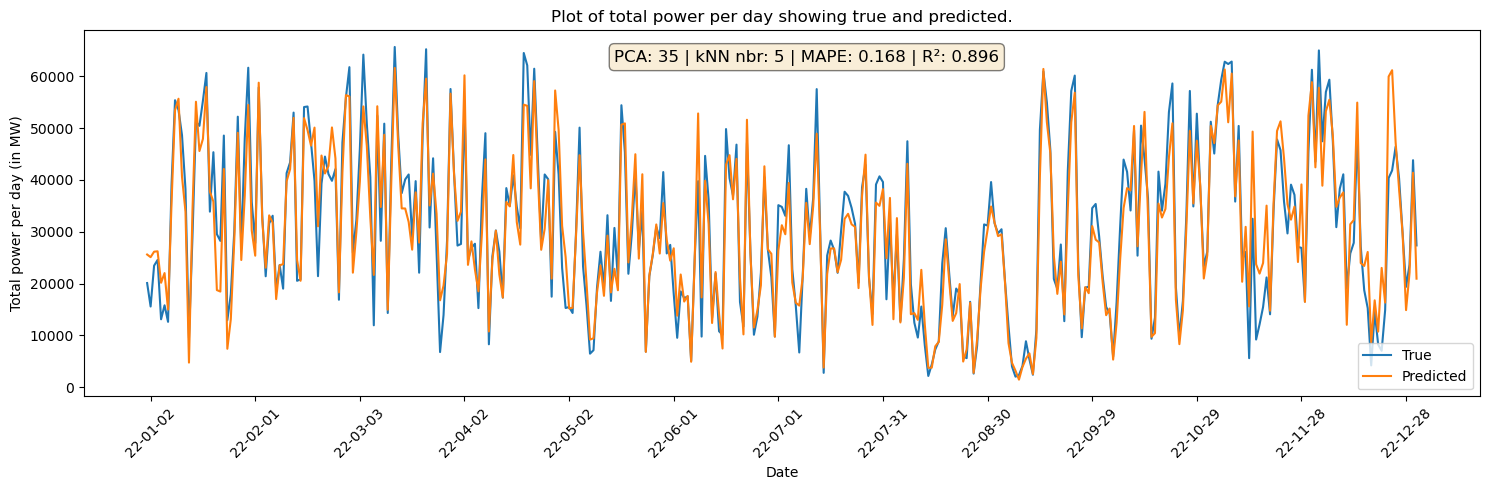

In [4]:
## Syntax to call the function with no arguments
preds, true_aggregates, mape, r2 = knn_cv_main()


Please enter forecast start date in the format YYYY-MM-DD.The date should be in between 2019-03-02 to 2023-12-31.

You have entered: 2022-01-01.

Please enter forecast window (in days). It should be an integer between 1 or 365.

Your forecast window is days between: 2022-01-01 and 2022-12-31

Cross validation running on your prediction window...

Prediction done with: PCA comps = 10, knn nbr = 5. Error scores: cv_mape = 0.181, cv_R2 = 0.887.
Prediction done with: PCA comps = 10, knn nbr = 10. Error scores: cv_mape = 0.182, cv_R2 = 0.886.
Prediction done with: PCA comps = 10, knn nbr = 25. Error scores: cv_mape = 0.183, cv_R2 = 0.881.
Prediction done with: PCA comps = 10, knn nbr = 50. Error scores: cv_mape = 0.190, cv_R2 = 0.870.
Prediction done with: PCA comps = 20, knn nbr = 5. Error scores: cv_mape = 0.173, cv_R2 = 0.892.
Prediction done with: PCA comps = 20, knn nbr = 10. Error scores: cv_mape = 0.172, cv_R2 = 0.892.
Prediction done with: PCA comps = 20, knn nbr = 25. Error scores

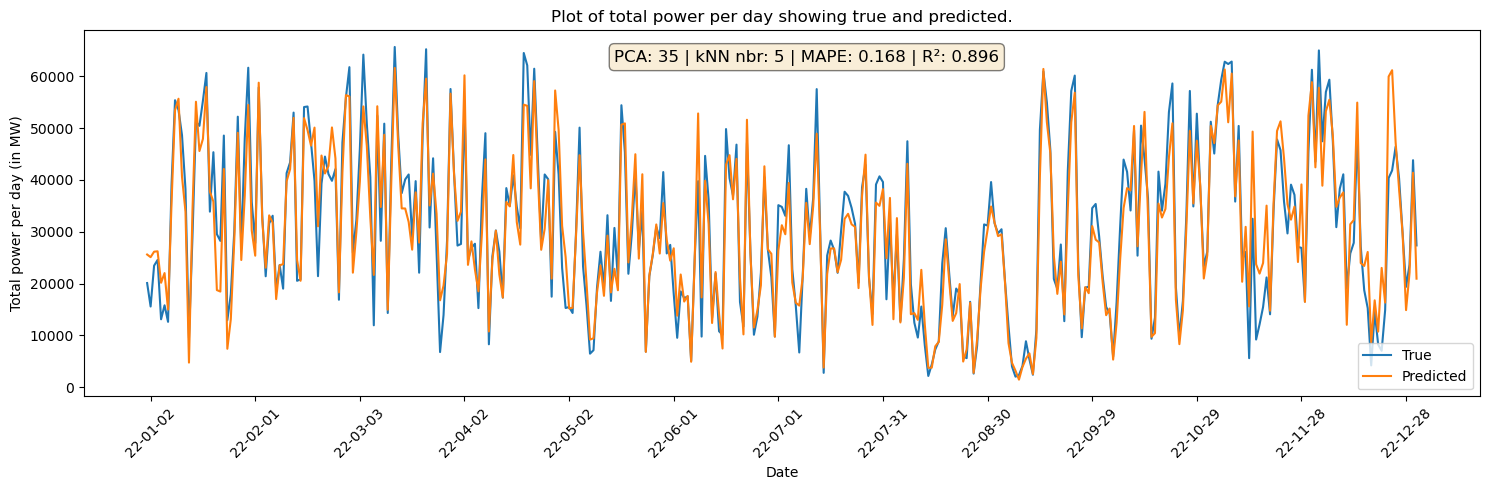

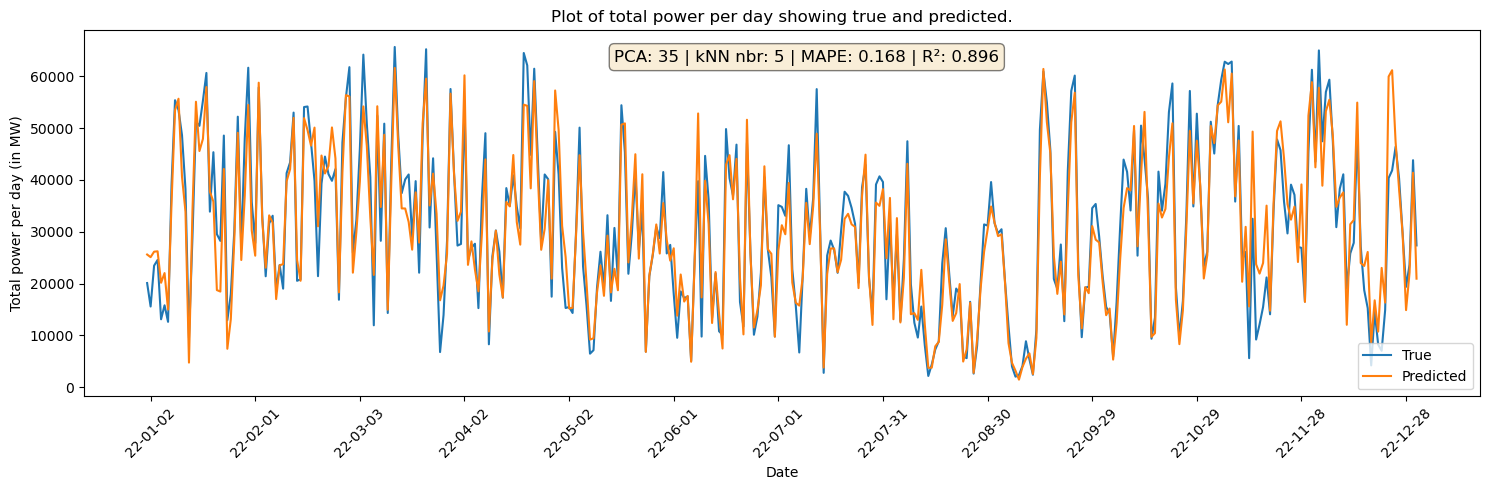

In [2]:
## Syntax to call the function with arguments
hyperparam_comb_index, hyperparam_comb_preds,  true_aggregates, cv_mapes, cv_r2s = knn_cv_main(
                                                                                    [10,20,30,35],[5,10,25,50])

After this point, this notebook contains the functions contained in the .py file. 

# kNN with cross-validation

In this notebook, for each pair `(pca_comp, n_nbr)`, we calculated the MAPE and R2 score for each such hyperparameter combinations by predicted on each day of a `test_window` (rather a validation window) and training on all the days before the `test_window`. We set the `test_window` to be the year 2022 for now.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from seaborn import set_style
import seaborn as sns

set_style("whitegrid")

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_percentage_error, r2_score

### Main Helper Functions

In [2]:
## Provides the list of days in yy-mm-dd format within the time_window
def list_of_days(time_window):
    assert type(time_window) ==  pd.core.indexes.datetimes.DatetimeIndex, ("TypeError: "
                                "time_window must be of type pandas.core.indexes.datetimes.DatetimeIndex.")
    return [x.strftime('%y-%m-%d') for x in time_window]


## Makes a column YearMonthDay: adds year in the MonthDay column in the format YY-MM-DD (eg 22-01-01)
## renames the column as YearMonthDay
def make_yymmdd_format(df):
    try:
        new_df = df
        new_df.time = pd.to_datetime(new_df.time).dt.tz_localize(None)
        #new_df = new_df.set_index('time')
        new_df['YearMonthDay'] = new_df['time'].apply(lambda x: x.strftime('%y-%m-%d'))
        new_df = new_df.drop(columns = ['MonthDay'])
        return new_df
    except:
        print("Incorrect dataframe passed to make_yymmdd_format.")

## Finds the true aggregate values of wind production per day of a given year
def true_aggregate_per_day(df, time_window):
    try:
        assert type(time_window) ==  pd.core.indexes.datetimes.DatetimeIndex, ("TypeError: "
                                "time_window must be of type pandas.core.indexes.datetimes.DatetimeIndex.")
        day_list = list_of_days(time_window)
        df_test = df[df.YearMonthDay.isin(day_list)]
        aggregates = {}
        for day in day_list:
            df_day = df_test[df_test['YearMonthDay'] == day]
            aggregates[day] = sum(np.array(df_day.Wind))
        return(aggregates)
    except:
        print("Incorrect dataframe passed to true_aggregate_per_day.")

In [5]:
## Splits train-test set based on start_date and end_date.
## The days between start_date and end_date are in the test set
## The days less than start_date are in the training set
def extract_train_test_data(df, start_date: pd.Timestamp, end_date = None):
    try:
        if end_date == None:
            end_date = start_date
        assert (type(start_date) == pd.Timestamp and type(end_date) == pd.Timestamp), ("TypeError: "
                                            "start_date and  end_date must be pandas.Timestamp type variable.")
        train_df = df[df['time'] < start_date]
        end_date = end_date.replace(hour=23)        ## by default the hour is 00:00:00, so replaced to make it 23:00:00
        test_df = df[(df['time'] >= start_date) & (df['time'] <= end_date)]
        return train_df, test_df
    except:
        print("Incorrect dataframe passed to extract_train_test_data.")

In [6]:
## Function to check different hyperparameters to fine-tune the model
def choose_pca_nbr_hyperparams():
    pca_comps = [30,33,35,36]   ## running with small set of combinations to manage runtime
    n_nbrs = [5,10]             ## chose these as these seem to provide better results
                                ## PCA more than 30 and knn nbr around or less than 10
                                ## for the final script, we'll include the best value
    return pca_comps, n_nbrs


## This function checks for TypeError and ValueError in the variable test_window
## Need to train the model on at least on year on data and we don't have power data after 2023, 
## so the test_window is set to satisfy between 2020-01-01 to 2023-12-31
def test_window_validity(test_window):
    assert type(test_window) == pd.core.indexes.datetimes.DatetimeIndex, ("TypeError: test_window must be of type "
            "pandas.core.indexes.datetimes.DatetimeIndex")
    test_window = test_window.sort_values()
    assert (pd.Timestamp(year=2020, month=1, day=1) <= test_window[0] 
            and test_window[-1] <= pd.Timestamp(year=2023, month=12, day=31)), ("ValueError: test_window must be "
            "between 2020-01-01 to 2023-12-31")
        

## Cross-validation second method: for each combination of (pca_comp, n_nbr), the function takes in a test_window,
## calls other helper functions to compute an array of predicted values for each day of the test_window
## (where the model is trained on all the days prior to the prediced day, 
## see function knn_using_particular_hyperparams_and_test_window), MAPE and R2 scores for that particular hyperparams.
## The function returns a indexing dictionary to keep track of hyperparams combination, a 2-d array with consisting 1-d arrays 
## corresponding to predicted values for each hyperparams combination, cv_MAPE and cv_R2 values corresponding to 
## each hyperparams combination

def cross_validation_main(df, test_window):
    test_window_validity(test_window)       ## testing that test_window is valid
    pca_comps , n_nbrs = choose_pca_nbr_hyperparams()
    hyperparam_comb_index = {}   # contains list of (pca_comb, n_bdr) values
                    # format  0: (pca_comps[0], n_nbrs[0]), 1: (pca_comps[0], n_nbrs[1]) and so on
    cv_mapes = []
    cv_r2s = []
    hyperparam_comb_preds = []
    
    for i in range(len(pca_comps)):
        for j in range(len(n_nbrs)):
            hyperparam_comb_index[len(n_nbrs)*i + j] = (pca_comps[i], n_nbrs[j])
            try:
                preds, true_aggregates = knn_using_particular_hyperparams_and_test_window(df, pca_comps[i], n_nbrs[j], test_window)

                mape= mean_absolute_percentage_error(y_pred = preds, y_true = true_aggregates)
                r2 = r2_score(y_pred = preds, y_true = true_aggregates)
                cv_mapes.append(mape)
                cv_r2s.append(r2)
                hyperparam_comb_preds.append(preds)

                print(f"Hyperparameters: PCA comps = {pca_comps[i]}, knn nbr = {n_nbrs[j]}, cv_mape = {mape:.3f}, cv_R2 = {r2:.3f}.")
            except:
                print(f"Error in hyperparameters combination: {(pca_comps[i], n_nbrs[j])}")
    return hyperparam_comb_index, hyperparam_comb_preds, cv_mapes, cv_r2s

## For each day in the test_window, this function trains a knn regressor model on all the day before that day,
## predicts on that day. Returns an array of predicted values for each day and an array with true aggregate for that day
def knn_using_particular_hyperparams_and_test_window(df, pca_comp, n_nbr, test_window):
    preds = []
    true_aggregates = []

    for test_day in test_window:

        true_aggregate = [float(x) for x in true_aggregate_per_day(df,pd.date_range(start=test_day,end=test_day, freq='d')).values()] 
                            # for just a day this array would have just 1 entry
        true_aggregates.append(true_aggregate[0])

        df_train, df_test = extract_train_test_data(df, test_day)
        pred = kNN_on_particular_train_test_splits(df_train, df_test, pca_comp, n_nbr)
                            # for just a day this array would have just 1 entry
        preds.append(pred[0])

        #print(f"Hyperparameters: {(pca_comp,n_nbr)}, test day: {test_day.strftime('%y-%m-%d')}, y_pred = {pred[0]:.1f}, y_true = {true_aggregate[0]:.1f}.")

    return preds, true_aggregates


## Takes in training and testing dataframes and a hyperparams combination of PCA and knn-neighbours
## and returns an array of predicted values corresponding to each day.
## Note: training is done on hourly data, predicted on hourly data and finally added the predicted values per day
def kNN_on_particular_train_test_splits(df_train, df_test, pca_comp, n_nbr):
    features = df_train.columns.drop(['Unnamed: 0', 'time', 'Year', 'YearMonthDay', 'Wind']) #extract the features

    pipe = Pipeline([('scale', StandardScaler()), ('pca', PCA(n_components= pca_comp))])
    pipe.fit(df_train[features])

    pca_train = pipe.transform(df_train[features])
    pca_test = pipe.transform(df_test[features])


    knn = KNeighborsRegressor(n_neighbors=n_nbr)
    knn.fit(pca_train, df_train.Wind)
    pred = knn.predict(pca_test)

    pred_per_day = [sum(pred[i:i+24]) for i in range(0, len(pred),24)]
    return pred_per_day

In [7]:
## Finding the best combination in terms of MAPE and R2 scores and printing the errors
def find_best_hyperparams_combination(cv_mapes, cv_r2s, hyperparam_comb_index):
    best_MAPE_idx = cv_mapes.index(min(cv_mapes))
    best_r2_idx = cv_r2s.index(max(cv_r2s))

    print(f"Best combination in terms of MAPE: pca = {hyperparam_comb_index[best_MAPE_idx][0]}, nbr = {hyperparam_comb_index[best_MAPE_idx][1]}, MAPE = {cv_mapes[best_MAPE_idx]:.3f}, R2 = {cv_r2s[best_MAPE_idx]:.3f}")
    print(f"Best combination in terms of R2 score: pca = {hyperparam_comb_index[best_r2_idx][0]}, nbr = {hyperparam_comb_index[best_r2_idx][1]}, MAPE = {cv_mapes[best_r2_idx]:.3f}, R2 = {cv_r2s[best_r2_idx]:.3f}")
    return best_MAPE_idx, best_r2_idx

In [8]:
## Ploting for the best combinations (each for best cv_mape_mean and cv_r2_mean) for each year
def plot_best_hyperparams_combination(df,hyperparam_comb_preds,best_MAPE_idx, best_r2_idx, 
                                      cv_mapes, cv_r2s,hyperparam_comb_index,test_window):
    fig, ax = plt.subplots(2, 1, figsize=(15, 2*5))
    criteria = {0: 'Best MAPE', 1: 'Best R2 Score'}
    best_MAPE_preds = hyperparam_comb_preds[best_MAPE_idx]
    best_r2_preds = hyperparam_comb_preds[best_r2_idx]

    df_train, df_test = extract_train_test_data(df, test_window.sort_values()[0], test_window.sort_values()[-1])
    true_aggregates = true_aggregate_per_day(df_test, test_window)
    days_list = list_of_days(test_window)

    for i in range(len(criteria)):
        ax[i].plot(days_list, true_aggregates.values(), label = 'True aggregates per day')
        ax[i].legend(loc='lower right')
        ax[i].tick_params(axis='x', rotation = 45)
        ax[i].set_xticks([])
        ax[i].set_xlabel('Date')
        ax[i].set_ylabel('Total power per day (in MW)')



    ax[0].plot(days_list, best_MAPE_preds, label = 'Best in terms of MAPE')
    ax[0].set_title(f"PCA = {hyperparam_comb_index[best_MAPE_idx][0]}, " 
                      f"nbr = {hyperparam_comb_index[best_MAPE_idx][1]}, MAPE = {cv_mapes[best_MAPE_idx]:.3f},"
                      f" R2 = {cv_r2s[best_MAPE_idx]:.3f} ")

    ax[1].plot(days_list, best_r2_preds, label = 'Best in terms of R2 score')
    ax[1].set_title(f"PCA = {hyperparam_comb_index[best_r2_idx][0]}, "
                        f"nbr = {hyperparam_comb_index[best_r2_idx][1]}, MAPE = {cv_mapes[best_r2_idx]:.3f}, "
                        f"R2 = {cv_r2s[best_r2_idx]:.3f}")

    plt.show()

# Feature Engineering

## Different feature trials

### Just wind speed

In [9]:
## testing window start_date and end_date
test_window_start_date = pd.Timestamp(year=2022, month= 1, day=1)
test_window_end_date = pd.Timestamp(year=2022, month= 12, day=31)
test_window = pd.date_range(start= test_window_start_date, end=test_window_end_date, freq="d")

In [ ]:
## load the fresh data frame
df = make_yymmdd_format(pd.read_csv("../../data/final_dataframes/main_training_dataframe.csv"))
df = df.drop(columns= #[f'wind_speed_10m_{i}' for i in range(1, 40)] + 
                                [f'temperature_2m_{i}' for i in range(1,40)] +
                                [f'wind_direction_10m_{i}' for i in range(1,40)]+
                                [f'relative_humidity_2m_{i}' for i in range(1,40)] )
hyperparam_comb_index, hyperparam_comb_preds, cv_mapes, cv_r2s = cross_validation_main(df, test_window)
print('\n\n')
## call find_best_hyperparams_combination to see the best MAPE and R2 scores and extract the best combinations
best_MAPE_idx, best_r2_idx = find_best_hyperparams_combination(cv_mapes, cv_r2s, hyperparam_comb_index)

Hyperparameters: PCA comps = 30, knn nbr = 5, cv_mape = 0.167, cv_R2 = 0.902.
Hyperparameters: PCA comps = 30, knn nbr = 10, cv_mape = 0.169, cv_R2 = 0.900.
Hyperparameters: PCA comps = 33, knn nbr = 5, cv_mape = 0.167, cv_R2 = 0.902.
Hyperparameters: PCA comps = 33, knn nbr = 10, cv_mape = 0.169, cv_R2 = 0.900.
Hyperparameters: PCA comps = 35, knn nbr = 5, cv_mape = 0.167, cv_R2 = 0.903.
Hyperparameters: PCA comps = 35, knn nbr = 10, cv_mape = 0.169, cv_R2 = 0.900.
Hyperparameters: PCA comps = 36, knn nbr = 5, cv_mape = 0.166, cv_R2 = 0.903.
Hyperparameters: PCA comps = 36, knn nbr = 10, cv_mape = 0.169, cv_R2 = 0.900.



Best combination in terms of MAPE: pca = 36, nbr = 5, MAPE = 0.166, R2 = 0.903
Best combination in terms of R2 score: pca = 36, nbr = 5, MAPE = 0.166, R2 = 0.903


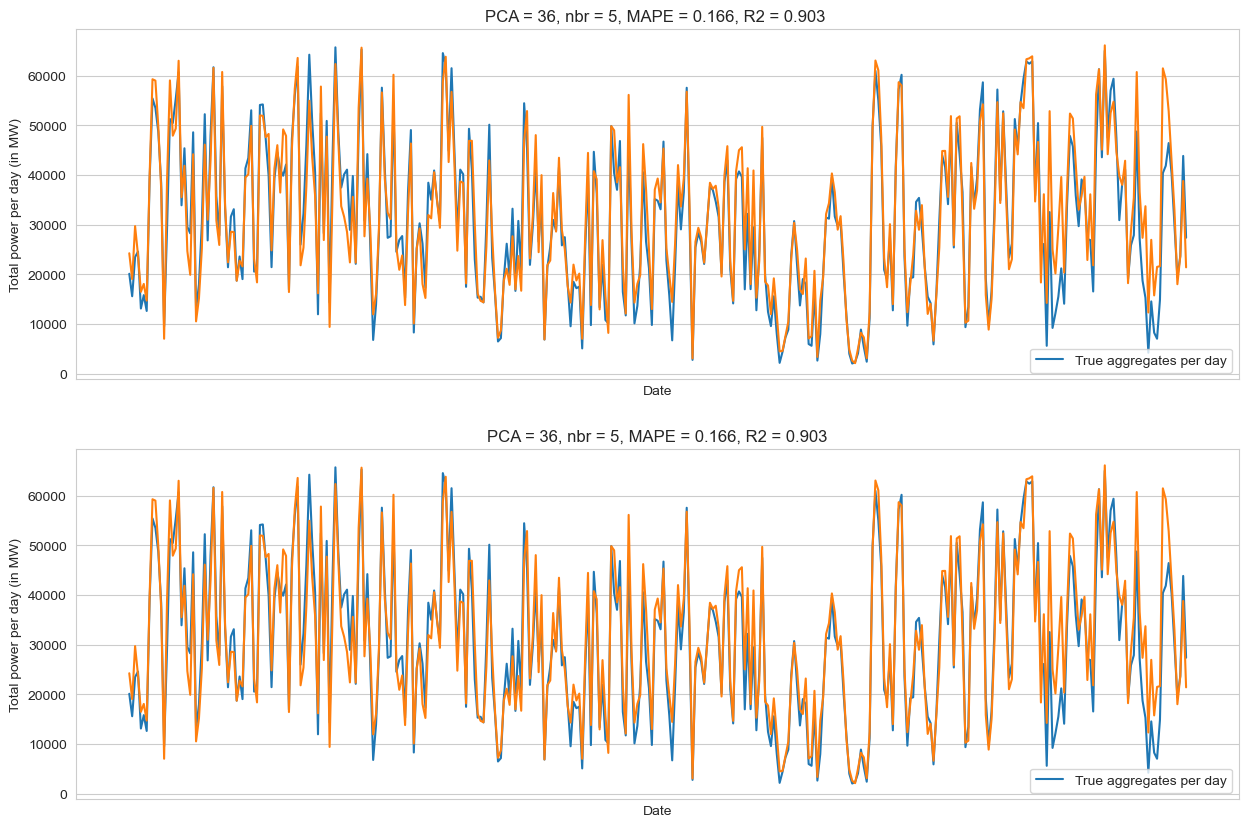

In [11]:
## Optional: plot the predicted vs true values for the best hyperparams 
plot_best_hyperparams_combination(df,hyperparam_comb_preds, best_MAPE_idx, best_r2_idx,
                                cv_mapes, cv_r2s, hyperparam_comb_index, test_window)

### Just wind speed cubed

In [ ]:
def speed_cubed(df):    
    new_cols = []
    for i in range(1, 40):
        spd_col = f'wind_speed_10m_{i}'
        cubed_col = df[spd_col] ** 3
        
        new_cols.append(pd.DataFrame({
            f'{spd_col}_cubed': cubed_col
        }))

    # Concatenate all new columns at once
    df_new = pd.concat([df.drop(columns= [f'wind_speed_10m_{i}' for i in range(1, 40)] +
                                [f'temperature_2m_{i}' for i in range(1,40)] +
                                [f'wind_direction_10m_{i}' for i in range(1,40)]+
                                [f'relative_humidity_2m_{i}' for i in range(1,40)])] + new_cols, axis=1)

    cubed_df = df_new.copy()  # defragment
    return cubed_df

In [ ]:
## load the fresh data frame
df = speed_cubed(make_yymmdd_format(pd.read_csv("../../data/final_dataframes/main_training_dataframe.csv")))

hyperparam_comb_index, hyperparam_comb_preds, cv_mapes, cv_r2s = cross_validation_main(df, test_window)
print('\n\n')
## call find_best_hyperparams_combination to see the best MAPE and R2 scores and extract the best combinations
best_MAPE_idx, best_r2_idx = find_best_hyperparams_combination(cv_mapes, cv_r2s, hyperparam_comb_index)

Hyperparameters: PCA comps = 30, knn nbr = 5, cv_mape = 0.159, cv_R2 = 0.906.
Hyperparameters: PCA comps = 30, knn nbr = 10, cv_mape = 0.159, cv_R2 = 0.906.
Hyperparameters: PCA comps = 33, knn nbr = 5, cv_mape = 0.158, cv_R2 = 0.907.
Hyperparameters: PCA comps = 33, knn nbr = 10, cv_mape = 0.159, cv_R2 = 0.906.
Hyperparameters: PCA comps = 35, knn nbr = 5, cv_mape = 0.158, cv_R2 = 0.907.
Hyperparameters: PCA comps = 35, knn nbr = 10, cv_mape = 0.158, cv_R2 = 0.906.
Hyperparameters: PCA comps = 36, knn nbr = 5, cv_mape = 0.157, cv_R2 = 0.907.
Hyperparameters: PCA comps = 36, knn nbr = 10, cv_mape = 0.158, cv_R2 = 0.906.



Best combination in terms of MAPE: pca = 36, nbr = 5, MAPE = 0.157, R2 = 0.907
Best combination in terms of R2 score: pca = 35, nbr = 5, MAPE = 0.158, R2 = 0.907


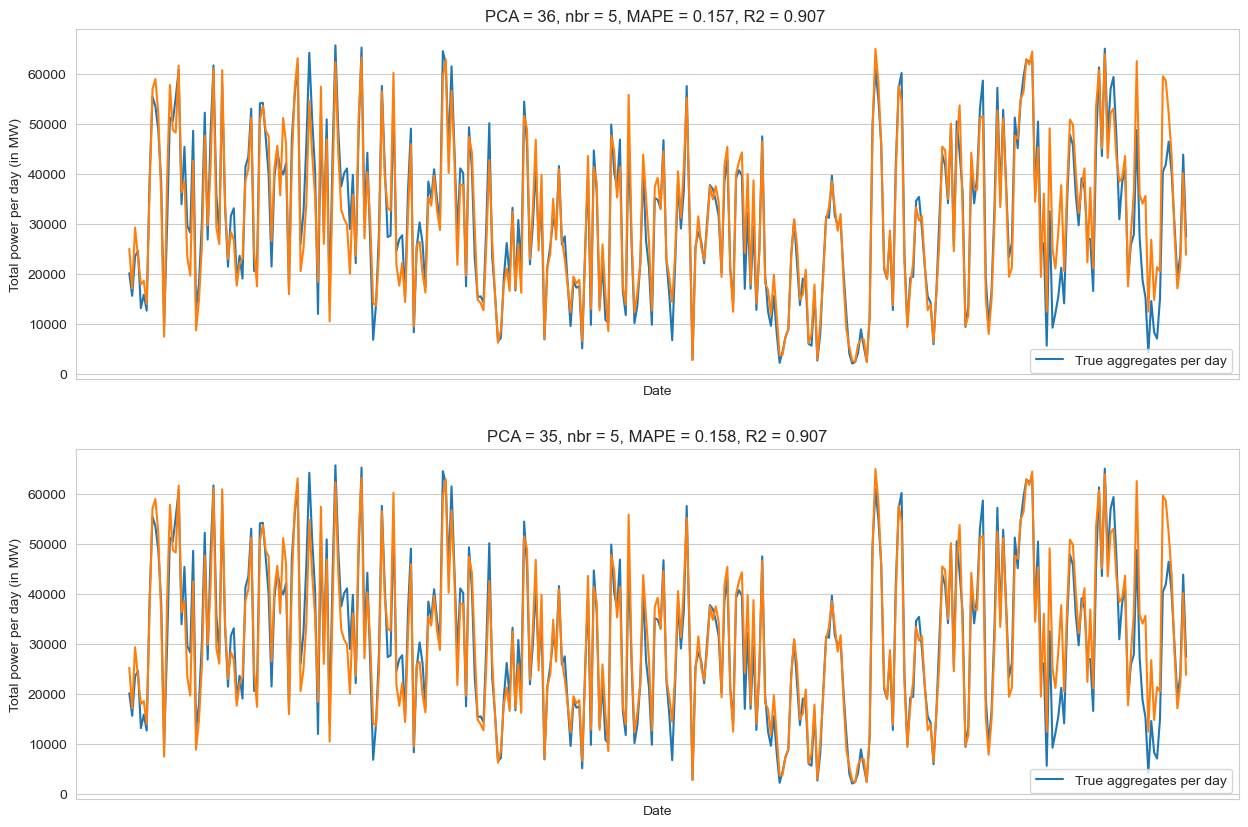

In [14]:
## Optional: plot the predicted vs true values for the best hyperparams 
plot_best_hyperparams_combination(df,hyperparam_comb_preds, best_MAPE_idx, best_r2_idx,
                                cv_mapes, cv_r2s, hyperparam_comb_index, test_window)

### Only speed cubed divided by temperature

In [ ]:
def speed_cubed_div_temp(df):    
    new_cols = []
    for i in range(1, 40):
        spd_col = f'wind_speed_10m_{i}'
        temp_col = f'temperature_2m_{i}'

        final_col = (df[spd_col] ** 3)/ (df[temp_col].values + 273) #divide by temperature in Kelvin scale
        
        new_cols.append(pd.DataFrame({
            f'{spd_col}_cubed_div_temp': final_col
        }))

    # Concatenate all new columns at once
    df_new = pd.concat([df.drop(columns= [f'wind_speed_10m_{i}' for i in range(1, 40)] +
                                [f'temperature_2m_{i}' for i in range(1,40)] +
                                [f'wind_direction_10m_{i}' for i in range(1,40)]+
                                [f'relative_humidity_2m_{i}' for i in range(1,40)])] + new_cols, axis=1)

    final_df = df_new.copy()  # defragment
    return final_df

In [ ]:
## load the fresh data frame
df = speed_cubed_div_temp(make_yymmdd_format(pd.read_csv("../../data/final_dataframes/main_training_dataframe.csv")))
hyperparam_comb_index, hyperparam_comb_preds, cv_mapes, cv_r2s = cross_validation_main(df, test_window)
print('\n\n')
## call find_best_hyperparams_combination to see the best MAPE and R2 scores and extract the best combinations
best_MAPE_idx, best_r2_idx = find_best_hyperparams_combination(cv_mapes, cv_r2s, hyperparam_comb_index)

Hyperparameters: PCA comps = 30, knn nbr = 5, cv_mape = 0.155, cv_R2 = 0.909.
Hyperparameters: PCA comps = 30, knn nbr = 10, cv_mape = 0.156, cv_R2 = 0.907.
Hyperparameters: PCA comps = 33, knn nbr = 5, cv_mape = 0.155, cv_R2 = 0.909.
Hyperparameters: PCA comps = 33, knn nbr = 10, cv_mape = 0.156, cv_R2 = 0.907.
Hyperparameters: PCA comps = 35, knn nbr = 5, cv_mape = 0.155, cv_R2 = 0.909.
Hyperparameters: PCA comps = 35, knn nbr = 10, cv_mape = 0.156, cv_R2 = 0.907.
Hyperparameters: PCA comps = 36, knn nbr = 5, cv_mape = 0.155, cv_R2 = 0.909.
Hyperparameters: PCA comps = 36, knn nbr = 10, cv_mape = 0.156, cv_R2 = 0.907.



Best combination in terms of MAPE: pca = 35, nbr = 5, MAPE = 0.155, R2 = 0.909
Best combination in terms of R2 score: pca = 35, nbr = 5, MAPE = 0.155, R2 = 0.909


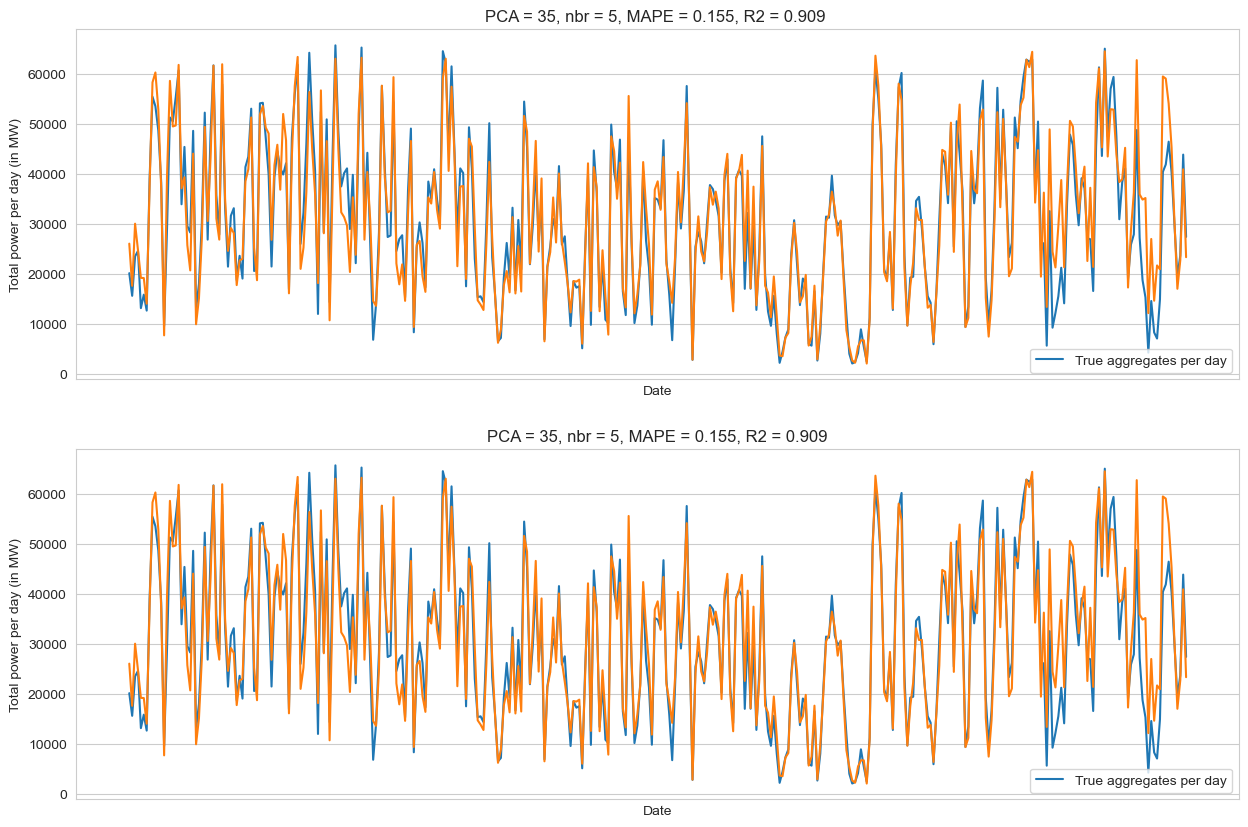

In [ ]:
## Optional: plot the predicted vs true values for the best hyperparams 
plot_best_hyperparams_combination(df,hyperparam_comb_preds, best_MAPE_idx, best_r2_idx,
                                cv_mapes, cv_r2s, hyperparam_comb_index, test_window)